In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import time

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

# Load Fashion-MNIST Dataset

In [2]:
fashion_mnist = keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


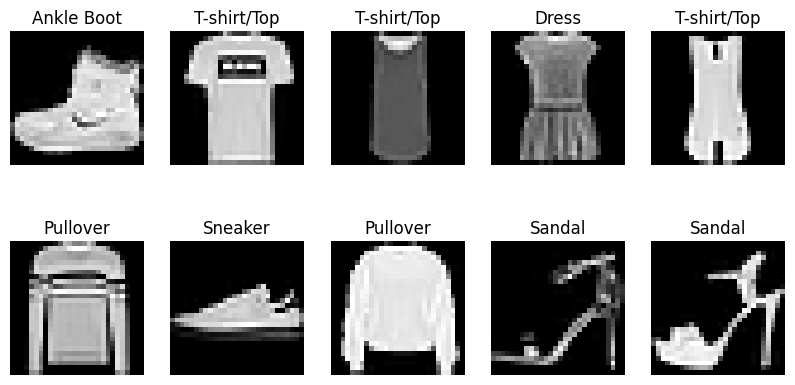

In [3]:
class_names = [
    'T-shirt/Top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

# Data Preprocessing

In [4]:
# CNN preprocessing

X_train_cnn = X_train / 255.0
X_test_cnn = X_test / 255.0

X_train_cnn = X_train_cnn.reshape(-1,28,28,1)
X_test_cnn = X_test_cnn.reshape(-1,28,28,1)

# Random Forest preprocessing

X_train_rf = X_train.reshape(len(X_train),784)
X_test_rf = X_test.reshape(len(X_test),784)

# CNN Implementation

In [5]:
cnn = keras.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.3),

    layers.Dense(
        10,
        activation='softmax'
    )
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

#Train CNN

In [ ]:
start = time.time()

history = cnn.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

cnn_time = time.time() - start

print("CNN Training Time:", cnn_time)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 55ms/step - accuracy: 0.8000 - loss: 0.5540 - val_accuracy: 0.8695 - val_loss: 0.3647
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 114s 94ms/step - accuracy: 0.8679 - loss: 0.3638 - val_accuracy: 0.8862 - val_loss: 0.3110
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 94ms/step - accuracy: 0.8851 - loss: 0.3139 - val_accuracy: 0.8960 - val_loss: 0.2782
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 53s 63ms/step - accuracy: 0.8982 - loss: 0.2808 - val_accuracy: 0.9025 - val_loss: 0.2615
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 74s 54ms/step - accuracy: 0.9069 - loss: 0.2565 - val_accuracy: 0.9093 - val_loss: 0.2520
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9129 - loss: 0.2402 - val_accuracy: 0.9027 - val_loss: 0.2652
Epoch 7/10


In [ ]:
cnn_train_pred = np.argmax(
    cnn.predict(X_train_cnn),
    axis=1
)

cnn_test_pred = np.argmax(
    cnn.predict(X_test_cnn),
    axis=1
)

print("CNN Train Accuracy:",
      accuracy_score(y_train, cnn_train_pred))

print("CNN Test Accuracy:",
      accuracy_score(y_test, cnn_test_pred))

In [ ]:
cm = confusion_matrix(
    y_test,
    cnn_test_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("CNN Test Confusion Matrix")
plt.show()

In [ ]:
cnn_precision = precision_score(
    y_test,
    cnn_test_pred,
    average=None
)

cnn_recall = recall_score(
    y_test,
    cnn_test_pred,
    average=None
)

cnn_results = pd.DataFrame({
    "Class": class_names,
    "Precision": cnn_precision,
    "Recall": cnn_recall
})

cnn_results

# Random Forest Implementation

In [ ]:
start = time.time()

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_rf,y_train)

rf_time = time.time() - start

print("RF Training Time:", rf_time)

In [ ]:
rf_train_pred = rf.predict(X_train_rf)

rf_test_pred = rf.predict(X_test_rf)

print("RF Train Accuracy:",
      accuracy_score(y_train, rf_train_pred))

print("RF Test Accuracy:",
      accuracy_score(y_test, rf_test_pred))

#RF Confusion Matrix

In [ ]:
cm = confusion_matrix(
    y_test,
    rf_test_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("RF Test Confusion Matrix")
plt.show()

#RF Precision Recall Table

In [ ]:
rf_precision = precision_score(
    y_test,
    rf_test_pred,
    average=None
)

rf_recall = recall_score(
    y_test,
    rf_test_pred,
    average=None
)

rf_results = pd.DataFrame({
    "Class": class_names,
    "Precision": rf_precision,
    "Recall": rf_recall
})

rf_results

#Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model":["CNN","Random Forest"],
    "Train Accuracy":[
        accuracy_score(y_train,cnn_train_pred),
        accuracy_score(y_train,rf_train_pred)
    ],
    "Test Accuracy":[
        accuracy_score(y_test,cnn_test_pred),
        accuracy_score(y_test,rf_test_pred)
    ],
    "Training Time (s)":[
        cnn_time,
        rf_time
    ]
})

comparison

# Discussion

Analyze:

- Worst performing classes
- Misclassified categories
- CNN vs Random Forest comparison
- Production recommendation

Typically:

Shirt, Pullover, Coat and T-shirt/Top show the highest confusion because they share similar visual characteristics.

CNN usually outperforms Random Forest because it preserves spatial information while Random Forest uses flattened pixel vectors.

In [ ]:
print("CNN Classification Report")

print(
    classification_report(
        y_test,
        cnn_test_pred,
        target_names=class_names
    )
)

print("RF Classification Report")

print(
    classification_report(
        y_test,
        rf_test_pred,
        target_names=class_names
    )
)